In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict, Counter

In [2]:
def createDf(data):
    reformed_data = []
    for exp in data:
        base_data = { k:v for k,v in exp.items() if k != "track" }
        for class_name, class_info in exp["track"].items():
            for n_frame, frame_tracks in enumerate(class_info):
                for tracker_id, player_dict in frame_tracks.items():
                    row = base_data.copy()
                    row.update({'class_name': class_name, 'frame': n_frame, 'tracker_id': tracker_id})
                    row.update({
                        "x1": player_dict["bbox"][0],
                        "y1": player_dict["bbox"][1],
                        "w": player_dict["bbox"][2] - player_dict["bbox"][0],
                        "h": player_dict["bbox"][3] - player_dict["bbox"][1],
                        "bbox_size": player_dict["bbox_size"],
                        "confidence": player_dict["confidence"],
                        "Real Madrid": player_dict["distances"]["Real Madrid"],
                        "Wolfsburgo": player_dict["distances"]["Wolfsburgo"],
                        "L": player_dict["shirt_color"][0],
                        "A": player_dict["shirt_color"][1],
                        "B": player_dict["shirt_color"][2],
                        "team": player_dict["team"]
                    } )
                    reformed_data.append(row)
    return pd.DataFrame(reformed_data)

In [3]:
with open("../tracks4.json", "r", encoding="utf-8") as f:
    data4 = json.load(f)
df4 = createDf(data4)
df4

,conf,mcf,mt,tt,class_name,frame,tracker_id,x1,y1,w,h,bbox_size,confidence,Real Madrid,Wolfsburgo,L,A,B,team
0,0.10,2,0.966,0.3,goalkeeper,133,27,153.004364,470.051788,27.224060,53.377533,4452,0.451804,144.023871,146.054486,87.456954,118.768212,140.397351,Real Madrid
1,0.10,2,0.966,0.3,goalkeeper,134,27,154.882828,470.190308,27.511353,51.916626,1833,0.389612,150.589774,156.256884,84.626667,153.626667,145.693333,Real Madrid
2,0.10,2,0.966,0.3,goalkeeper,139,28,169.865128,463.367462,18.848236,54.403168,3078,0.452710,152.360950,153.853881,79.217143,118.114286,141.588571,Real Madrid
3,0.10,2,0.966,0.3,goalkeeper,140,28,173.127899,462.986328,17.216904,53.583984,2703,0.462773,149.913068,151.634108,81.625000,118.925000,141.300000,Real Madrid
4,0.10,2,0.966,0.3,player,1,1,330.227692,492.715302,34.084656,76.827179,7854,0.871500,47.778496,1.575156,231.029973,99.702997,166.356948,Wolfsburgo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335120,0.16,6,0.990,0.7,referee,195,24,1770.570312,807.056580,27.450073,90.092651,7560,0.779709,195.176294,197.699087,35.721939,120.482143,135.954082,Real Madrid
335121,0.16,6,0.990,0.7,referee,196,24,1768.914673,806.742249,23.677734,90.965149,6552,0.826627,195.745445,198.709031,35.056150,121.614973,134.387701,Real Madrid
335122,0.16,6,0.990,0.7,referee,197,24,1766.900146,807.161682,24.223022,89.513672,3519,0.700062,49.788698,11.702397,219.419580,95.783217,164.825175,Wolfsburgo
335123,0.16,6,0.990,0.7,referee,198,24,1762.175903,807.629150,25.738037,90.594910,2916,0.620626,172.134315,174.119031,59.082474,119.402062,139.298969,Real Madrid


In [4]:
def analyze_tracks_no_gt(tracks, class_name="player"):
    frames = tracks[class_name]
    T = len(frames)
    id_frames, id_teams, id_colors, id_bboxes, id_conf, id_bbox_sizes = defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), defaultdict(list), 
    
    for t, frame_dict in enumerate(frames):
        for tid, info in frame_dict.items():
            id_frames[tid].append(t)
            id_teams[tid].append(info['team']), id_colors[tid].append(info['shirt_color']), id_bboxes[tid].append(info['bbox']), id_conf[tid].append(info['confidence']), id_bbox_sizes[tid].append(info['bbox_size'])
    
    # Metrics per id
    metrics = {}
    num_tracks = 0
    for tid, frames_seen in id_frames.items():
        
        if int(tid) > num_tracks:    num_tracks = int(tid)
        
        frames_seen_sorted = sorted(frames_seen)
        total_seen = len(frames_seen_sorted)
        coverage = total_seen / T

        gap_lengths = []
        movimiento_x = []
        movimiento_y = []
        prev = frames_seen_sorted[0]
        bbox_prev = id_bboxes[tid][0]
        for n_frame, f in enumerate(frames_seen_sorted[1:]):
            frame_gap = f - prev - 1
            if f != prev +1 :
                gap_lengths.append(frame_gap)

            bbox_current = id_bboxes[tid][n_frame]
            x1, y1, _, _ = bbox_current
            x1_prev, y1_prev, _, _ = bbox_prev

            dx, dy = (x1 - x1_prev) / (frame_gap+1), (y1 - y1_prev) / (frame_gap+1)

            movimiento_x.append(dx),  movimiento_y.append(dy)

            prev = f
            bbox_prev = bbox_current

        gaps = len(gap_lengths)
        mean_gap_len = np.mean(gap_lengths) if gap_lengths else 0.0
        mean_speed = np.mean(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        max_speed = np.max(np.sqrt(np.array(movimiento_x)**2 + np.array(movimiento_y)**2)) if movimiento_x else 0.0
        
        # team stability
        teams = id_teams.get(tid, [])
        team_mode = None
        flip_rate_static, flip_rate_dynamic, entropy = 0.0, 0.0, 0.0
        if teams:
            c = Counter(teams)
            team_mode, _ = c.most_common(1)[0]
            flips_static = sum(1 for x in teams if x != team_mode)
            flips_dynamic = sum(teams[i] != teams[i - 1] for i in range(1, len(teams)))
            flip_rate_static = flips_static / len(teams) if teams else None
            flip_rate_dynamic = flips_dynamic / (len(teams) - 1) if len(teams) > 1 else None

            # entropy
            ps = np.array(list(c.values()))/sum(c.values())
            entropy = -np.sum(ps * np.log2(ps + 1e-12))
        
        # color variance (if numeric)
        colors = np.array(id_colors.get(tid, []), dtype=float) if id_colors.get(tid) else None
        color_var = float(np.mean(np.var(colors, axis=0))) if colors is not None and len(colors)>0 else None
        color_diff = float(np.mean(np.linalg.norm(np.diff(colors, axis=0), axis=1))) if colors is not None and len(colors)>0 else None
        
        # bbox size var
        sizes = np.array(id_bbox_sizes.get(tid, []), dtype=float) if id_bbox_sizes.get(tid) else None
        size_cv = (np.std(sizes)/np.mean(sizes)) if sizes is not None and len(sizes)>1 else None
        
        metrics[tid] = {
            "coverage": coverage, "total_seen": total_seen, "fragments": gaps, "mean_gap_len": mean_gap_len, "mean_speed": mean_speed, "max_speed": max_speed,
            "team_mode": team_mode, "team_flip_rate_static": flip_rate_static, "team_flip_rate_dynamic": flip_rate_dynamic, "team_entropy": entropy,
            "color_var": color_var, "color_diff": color_diff, "bbox_size_cv": size_cv, "mean_confidence": float(np.mean(id_conf[tid])) if id_conf.get(tid) else None
        }
    # Summary stats
    covs = [m["coverage"] for m in metrics.values()]
    total_seen = [m["total_seen"] for m in metrics.values()]
    frag = [m["fragments"] for m in metrics.values()]
    mean_gap_len = [m["mean_gap_len"] for m in metrics.values()]
    mean_speed = [m["mean_speed"] for m in metrics.values()]
    max_speed = [m["max_speed"] for m in metrics.values()]
    flip_rates_static  = [m["team_flip_rate_static" ] for m in metrics.values() if m["team_flip_rate_static"] is not None]
    flip_rates_dynamic = [m["team_flip_rate_dynamic"] for m in metrics.values() if m["team_flip_rate_dynamic"] is not None]
    entropy = [m["team_entropy"] for m in metrics.values()]
    color_var = [m["color_var"] for m in metrics.values()]
    color_diff = [m["color_diff"] for m in metrics.values()]
    bbox_size = [m["bbox_size_cv"] for m in metrics.values() if m["bbox_size_cv"] is not None]
    confidence = [m["mean_confidence"] for m in metrics.values() if m["mean_confidence"] is not None]

    summary = {
        "n_tracks": num_tracks,
        "num_tracks": len(metrics),

        "mean_coverage": float(np.mean(covs)) if covs else 0.0, "median_coverage": float(np.median(covs)) if covs else 0.0, "25_coverage": float(np.quantile(covs, 0.25)) if covs else 0.0,
        "mean_fragments": float(np.mean(frag)) if frag else 0.0, "median_fragments": float(np.median(frag)) if frag else 0.0, "mean_gap_len_mean": float(np.mean(mean_gap_len)) if mean_gap_len else 0.0, "median_gap_len_mean": float(np.median(mean_gap_len)) if mean_gap_len else 0.0, 
        
        "pct_tracks_with_fragments": float(np.mean([1 if f>0 else 0 for f in frag])) if frag else 0.0,

        "mean_speed": float(np.mean(mean_speed) if mean_speed else 0.0),
        "max_speed": float(np.mean(max_speed) if max_speed else 0.0),
        
        "mean_team_flip_rate": float(np.mean(flip_rates_static)) if flip_rates_static else 0.0,
        "mean_team_flip_dynamic": float(np.mean(flip_rates_dynamic)) if flip_rates_dynamic else 0.0,
        "entropy": float(np.mean(entropy)) if entropy else 0.0,
        "color_var": float(np.mean(color_var)) if color_var else 0.0,
        "color_diff": float(np.mean(color_diff)) if color_diff else 0.0,
        "bbox_size": float(np.mean(bbox_size)) if bbox_size else 0.0,
        "confidence": float(np.mean(confidence)) if confidence else 0.0,
    }
    return metrics, summary


In [5]:
rows = []
for exp in data4:
    metrics, summary = analyze_tracks_no_gt(exp["track"])
    row = exp
    row["metrics"] = metrics
    row["summary"] = summary
    rows.append(row)

c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\hecto\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
for i, exp in enumerate(rows):
    exp['experiment_id'] = i
    
df_summary = pd.DataFrame([
    {
        **{k: v for k, v in exp.items() if k not in ['metrics', 'summary', 'track']},
        **exp['summary']
    }
    for exp in rows
])

df_summary

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,...,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
0,0.10,2,0.966,0.3,0,31,28,0.714821,0.9625,0.30000,...,0.464286,3.333784,15.545610,0.029551,0.050202,0.142706,232.420825,NaN,0.373119,0.734256
1,0.10,4,0.966,0.3,1,27,24,0.826042,0.9650,0.92375,...,0.500000,3.624238,18.394462,0.027483,0.050091,0.165102,292.564203,12.345471,0.397305,0.764044
2,0.10,6,0.966,0.3,2,25,23,0.855217,0.9650,0.92250,...,0.521739,3.718905,18.971720,0.043099,0.065384,0.238702,464.749640,17.853407,0.413412,0.779623
3,0.10,2,0.980,0.3,3,31,28,0.715179,0.9625,0.31625,...,0.464286,3.303189,15.462068,0.030017,0.051210,0.144953,228.056852,NaN,0.374492,0.729767
4,0.10,4,0.980,0.3,4,27,24,0.826042,0.9650,0.92375,...,0.500000,3.624238,18.394462,0.027483,0.050091,0.165102,292.564203,12.345471,0.397305,0.764044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,0.16,4,0.980,0.7,76,24,22,0.843409,0.9575,0.79750,...,0.590909,3.554958,19.466502,0.087715,0.122507,0.403739,443.360869,18.288177,0.425818,0.813776
77,0.16,6,0.980,0.7,77,25,22,0.813864,0.9425,0.73875,...,0.500000,3.476644,18.034544,0.143184,0.180961,0.556861,502.922637,22.171510,0.472379,0.814520
78,0.16,2,0.990,0.7,78,25,23,0.827609,0.9650,0.79250,...,0.521739,3.602921,19.105106,0.052211,0.076560,0.271340,415.197989,16.220527,0.410820,0.802457
79,0.16,4,0.990,0.7,79,24,22,0.843636,0.9575,0.79750,...,0.590909,3.542711,18.500181,0.084457,0.117107,0.391583,441.234365,18.003537,0.425615,0.813929


In [7]:
rows_detailed = []
for exp in rows:
    exp_info = {k: v for k, v in exp.items() if k not in ['metrics', 'summary', 'track']}
    for tid, m in exp['metrics'].items():
        rows_detailed.append({
            **exp_info,
            "track_id": tid,
            **m
        })

df_tracks = pd.DataFrame(rows_detailed)
df_tracks

,conf,mcf,mt,tt,experiment_id,track_id,coverage,total_seen,fragments,mean_gap_len,mean_speed,max_speed,team_mode,team_flip_rate_static,team_flip_rate_dynamic,team_entropy,color_var,color_diff,bbox_size_cv,mean_confidence
0,0.10,2,0.966,0.3,0,1,0.985,197,0,0.000000,3.188777,10.611729,Wolfsburgo,0.020305,0.040816,1.431472e-01,137.765082,7.058456,0.427225,0.838150
1,0.10,2,0.966,0.3,0,2,0.985,197,1,2.000000,3.244185,15.803012,Wolfsburgo,0.035533,0.040816,2.214221e-01,170.364248,7.699762,0.329521,0.792376
2,0.10,2,0.966,0.3,0,3,0.995,199,0,0.000000,2.936419,9.268063,Real Madrid,0.005025,0.010101,4.560648e-02,222.624870,6.402375,0.364280,0.782897
3,0.10,2,0.966,0.3,0,4,0.995,199,0,0.000000,3.588869,14.408763,Wolfsburgo,0.005025,0.010101,4.560648e-02,21.857371,2.620839,0.435459,0.830752
4,0.10,2,0.966,0.3,0,5,0.995,199,0,0.000000,4.068428,15.645078,Real Madrid,0.000000,0.000000,-1.442823e-12,32.758284,2.566011,0.431945,0.857973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1907,0.16,6,0.990,0.7,80,19,0.570,114,6,2.833333,5.580873,51.726035,Real Madrid,0.315789,0.292035,8.997438e-01,825.108376,43.074576,0.796672,0.701912
1908,0.16,6,0.990,0.7,80,21,0.730,146,0,0.000000,3.936586,11.303362,Real Madrid,0.020548,0.041379,1.445061e-01,119.055907,7.731711,0.286353,0.863049
1909,0.16,6,0.990,0.7,80,22,0.655,131,0,0.000000,4.894417,12.267312,Wolfsburgo,0.030534,0.030769,1.970646e-01,101.535095,5.106515,0.298935,0.852329
1910,0.16,6,0.990,0.7,80,23,0.195,39,0,0.000000,0.899071,2.184148,Real Madrid,0.102564,0.131579,4.770713e-01,1210.844395,26.654661,0.260034,0.798818


In [8]:
df_summary = df_summary[df_summary["25_coverage"] > 0.6]
len(df_summary)

72

In [9]:
for c in df_summary.columns[:4]:
    print(df_summary[c].value_counts())

conf
0.10    24
0.13    24
0.16    24
Name: count, dtype: int64
mcf
4    27
6    27
2    18
Name: count, dtype: int64
mt
0.966    24
0.980    24
0.990    24
Name: count, dtype: int64
tt
0.5    27
0.7    27
0.3    18
Name: count, dtype: int64


In [10]:
df_summary = df_summary[df_summary["mean_team_flip_rate"] < 0.075]
len(df_summary)

54

In [11]:
for c in df_summary.columns[:4]:
    print(df_summary[c].value_counts())

conf
0.10    18
0.13    18
0.16    18
Name: count, dtype: int64
mcf
4    18
6    18
2    18
Name: count, dtype: int64
mt
0.966    18
0.980    18
0.990    18
Name: count, dtype: int64
tt
0.5    27
0.3    18
0.7     9
Name: count, dtype: int64


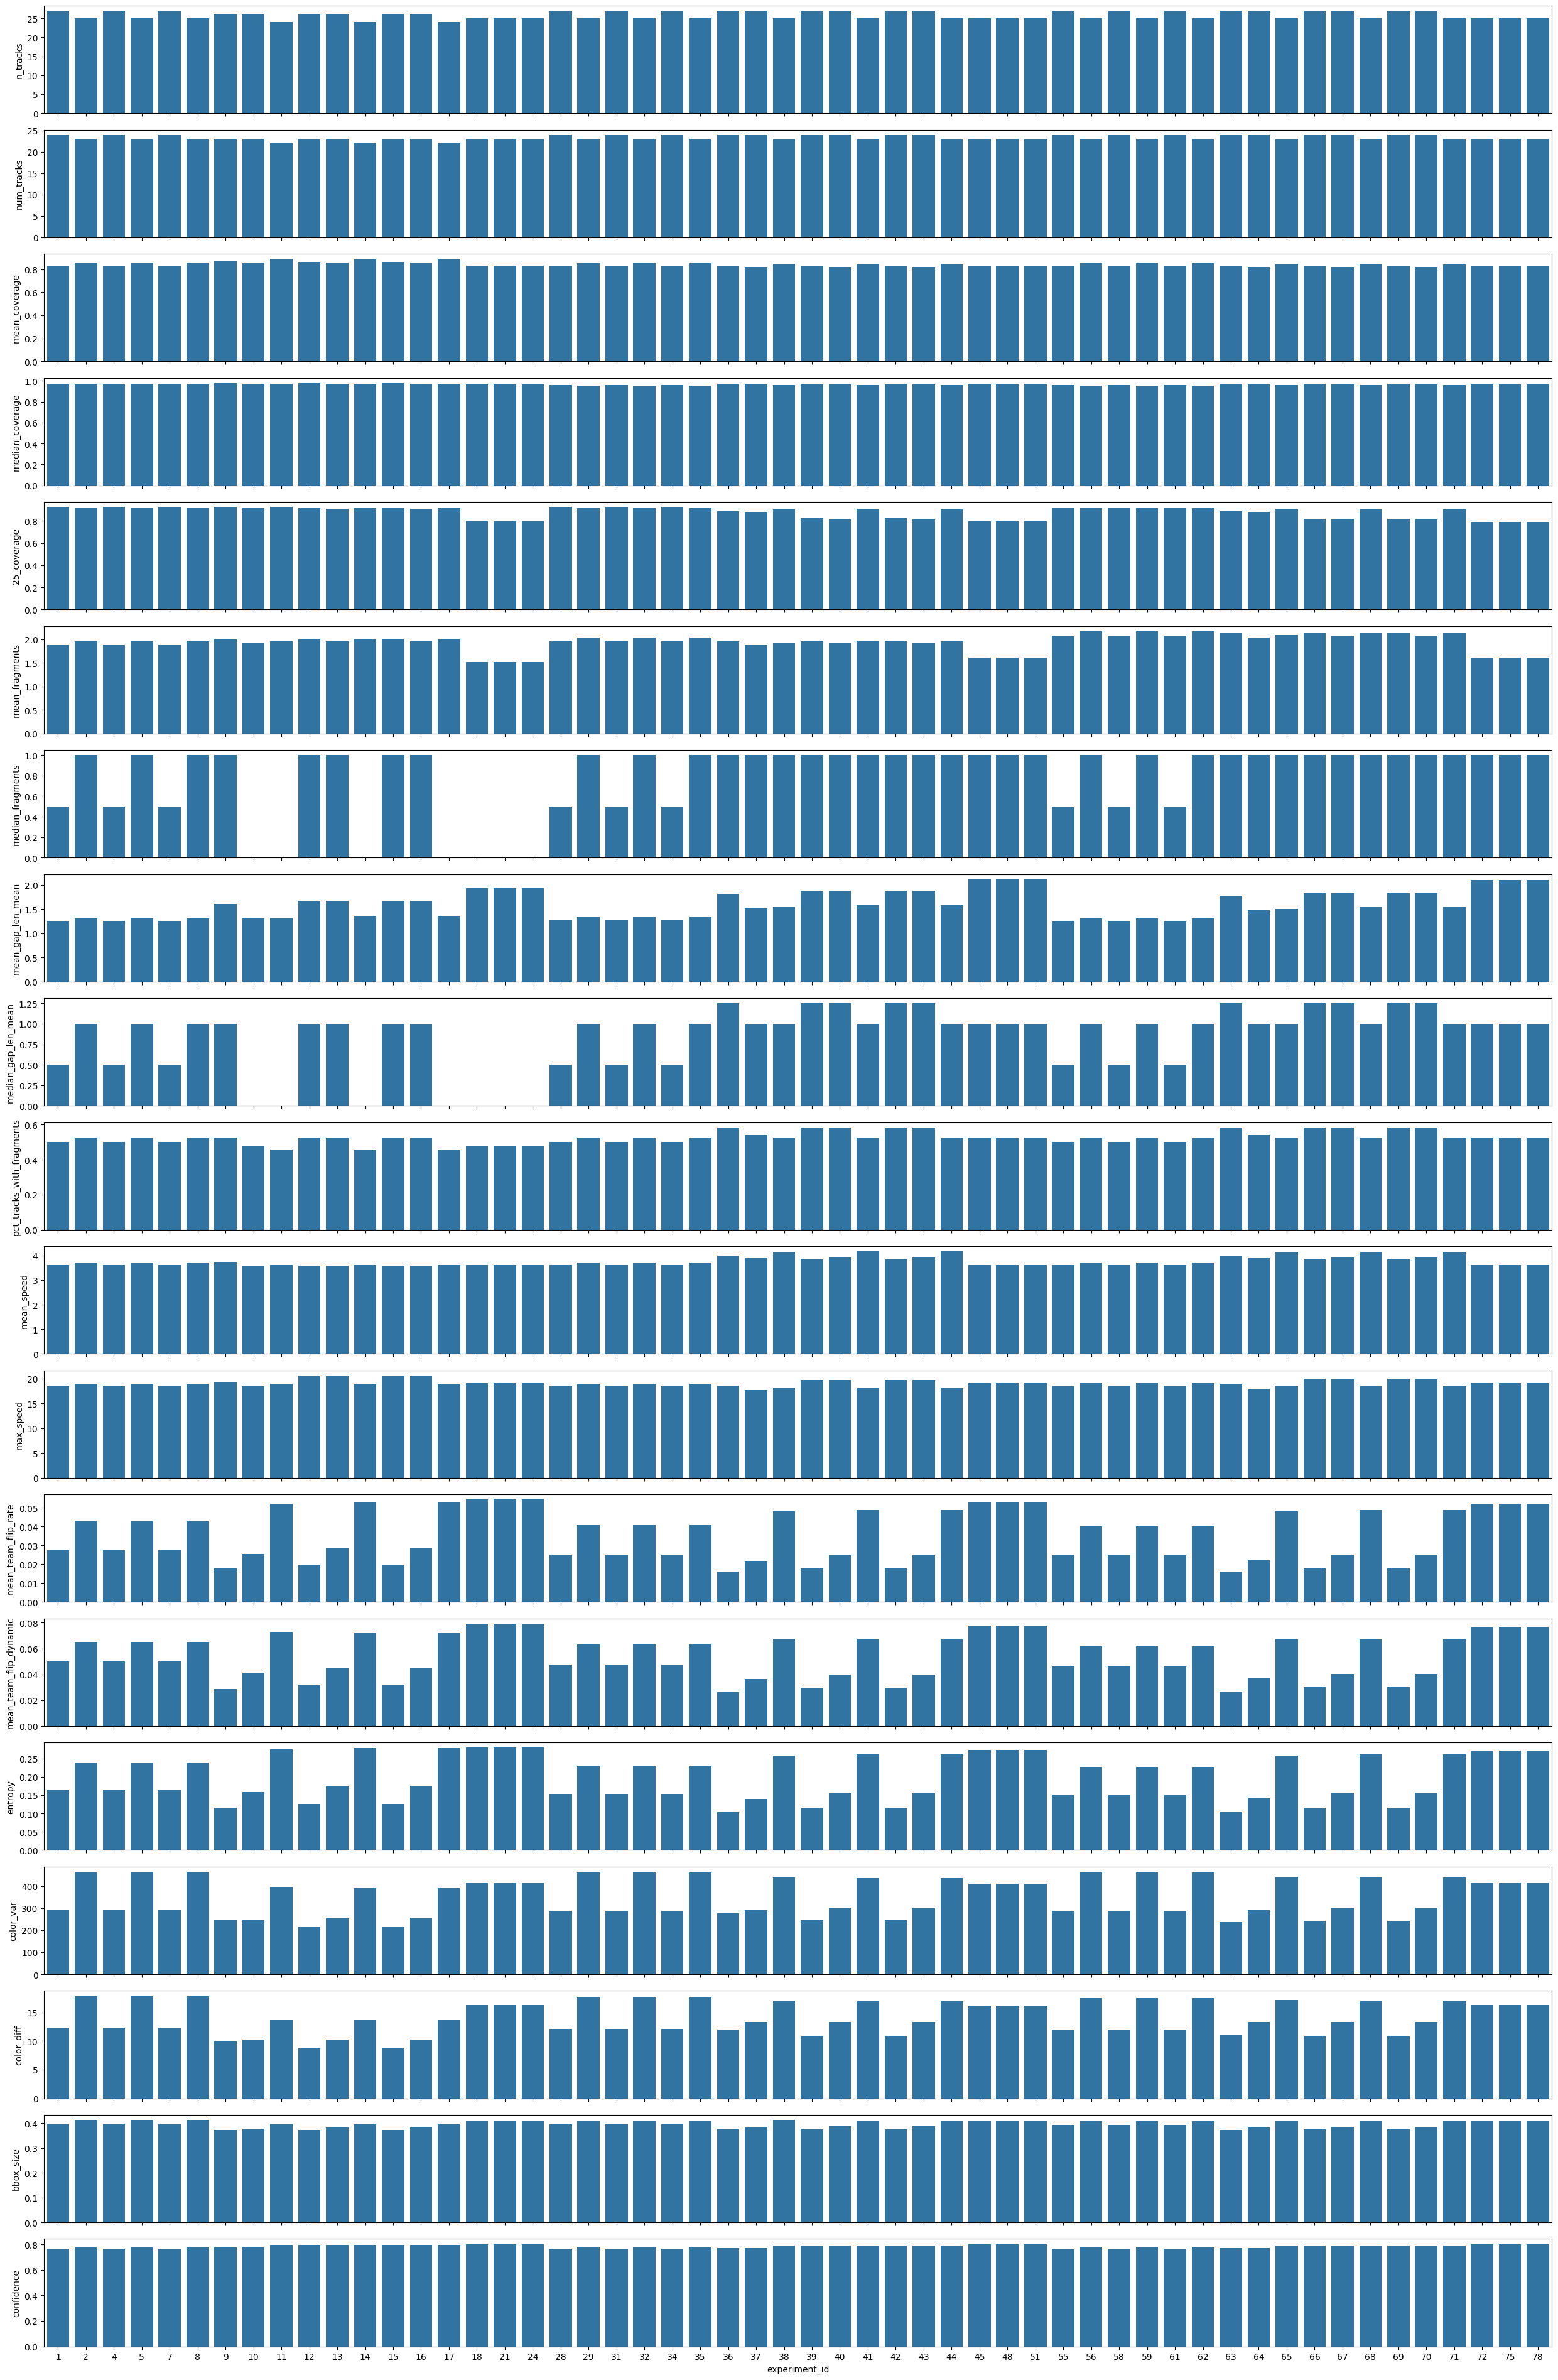

In [12]:
nRows = len(df_summary.columns[5:])
fig, axes = plt.subplots(nRows, 1, figsize=(25,2*nRows), sharex=True)
axes = axes.flatten()
for i, c in enumerate(df_summary.iloc[:, 5:]):
    sns.barplot(data=df_summary, x="experiment_id", y=c, ax=axes[i])
    axes[i].set_ylabel(c)

plt.tight_layout()
plt.show()

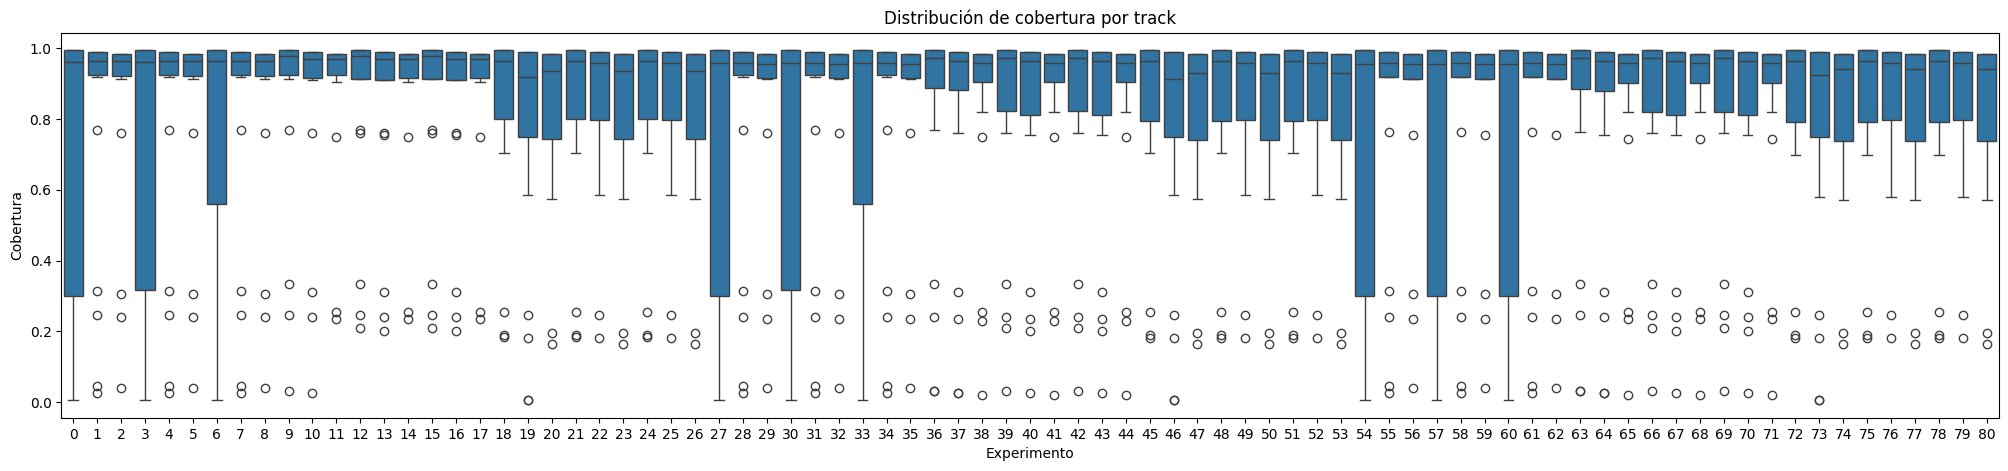

In [13]:
# Distribución de cobertura por track
plt.figure(figsize=(25, 5))
sns.boxplot(data=df_tracks, x="experiment_id", y="coverage")
plt.title("Distribución de cobertura por track")
plt.xlabel("Experimento")
plt.ylabel("Cobertura")
plt.show()

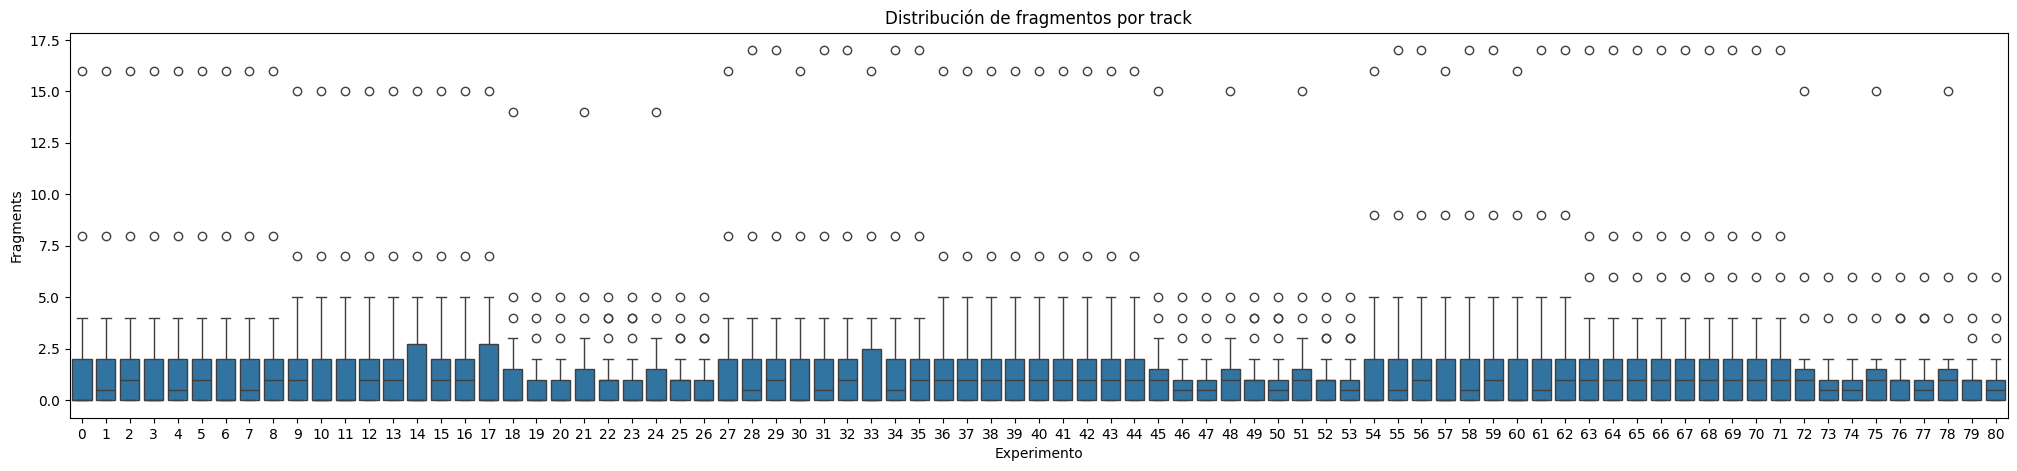

In [14]:
# Distribución de cobertura por track
plt.figure(figsize=(25, 5))
sns.boxplot(data=df_tracks, x="experiment_id", y="fragments")
plt.title("Distribución de fragmentos por track")
plt.xlabel("Experimento")
plt.ylabel("Fragments")
plt.show()

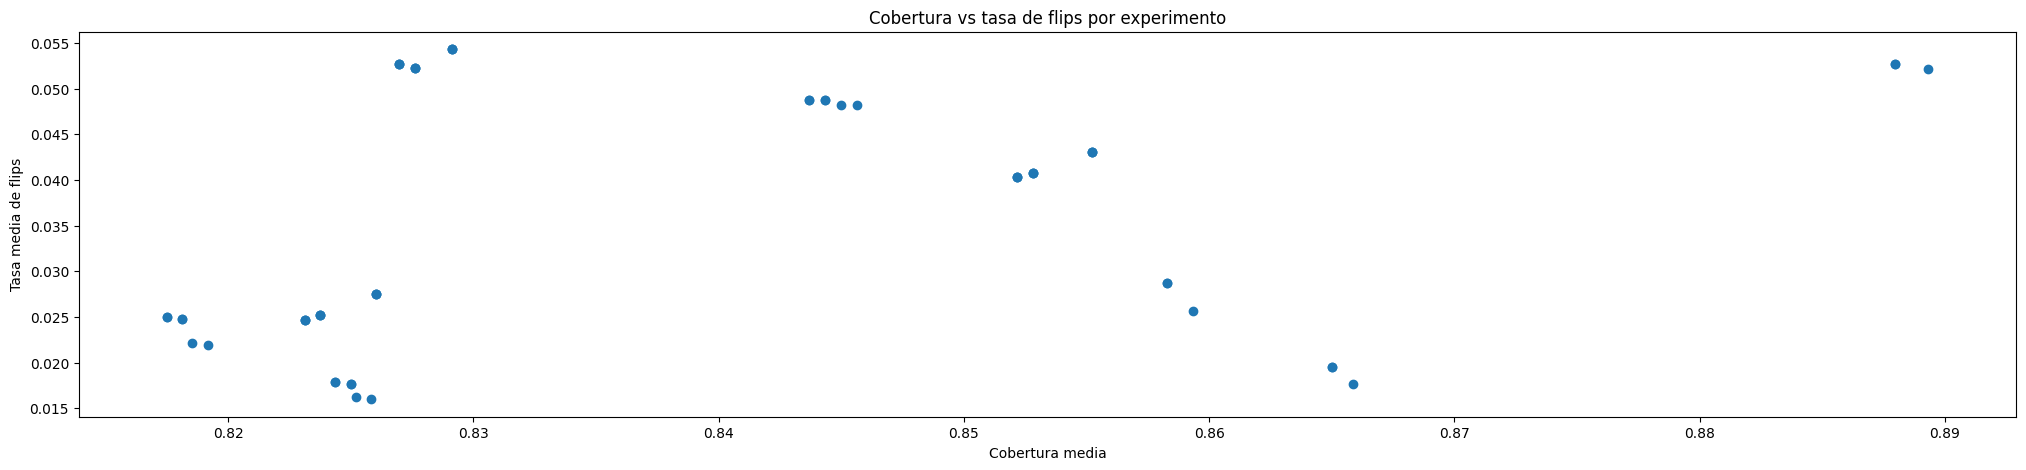

In [15]:
# Scatter: cobertura vs tasa de flips
plt.figure(figsize=(25, 5))
plt.scatter(df_summary["mean_coverage"], df_summary["mean_team_flip_rate"])
plt.xlabel("Cobertura media")
plt.ylabel("Tasa media de flips")
plt.title("Cobertura vs tasa de flips por experimento")
plt.show()

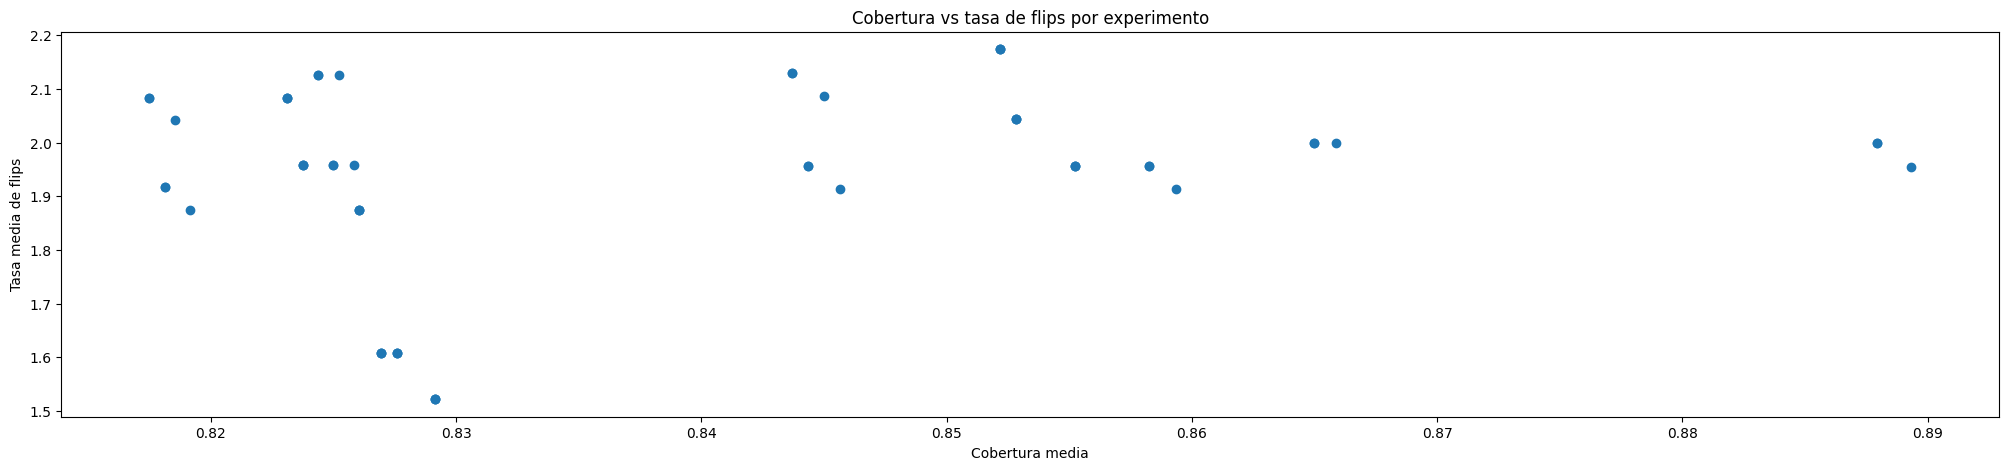

In [16]:
# Scatter: cobertura vs tasa de flips
plt.figure(figsize=(25, 5))
plt.scatter(df_summary["mean_coverage"], df_summary["mean_fragments"])
plt.xlabel("Cobertura media")
plt.ylabel("Tasa media de flips")
plt.title("Cobertura vs tasa de flips por experimento")
plt.show()

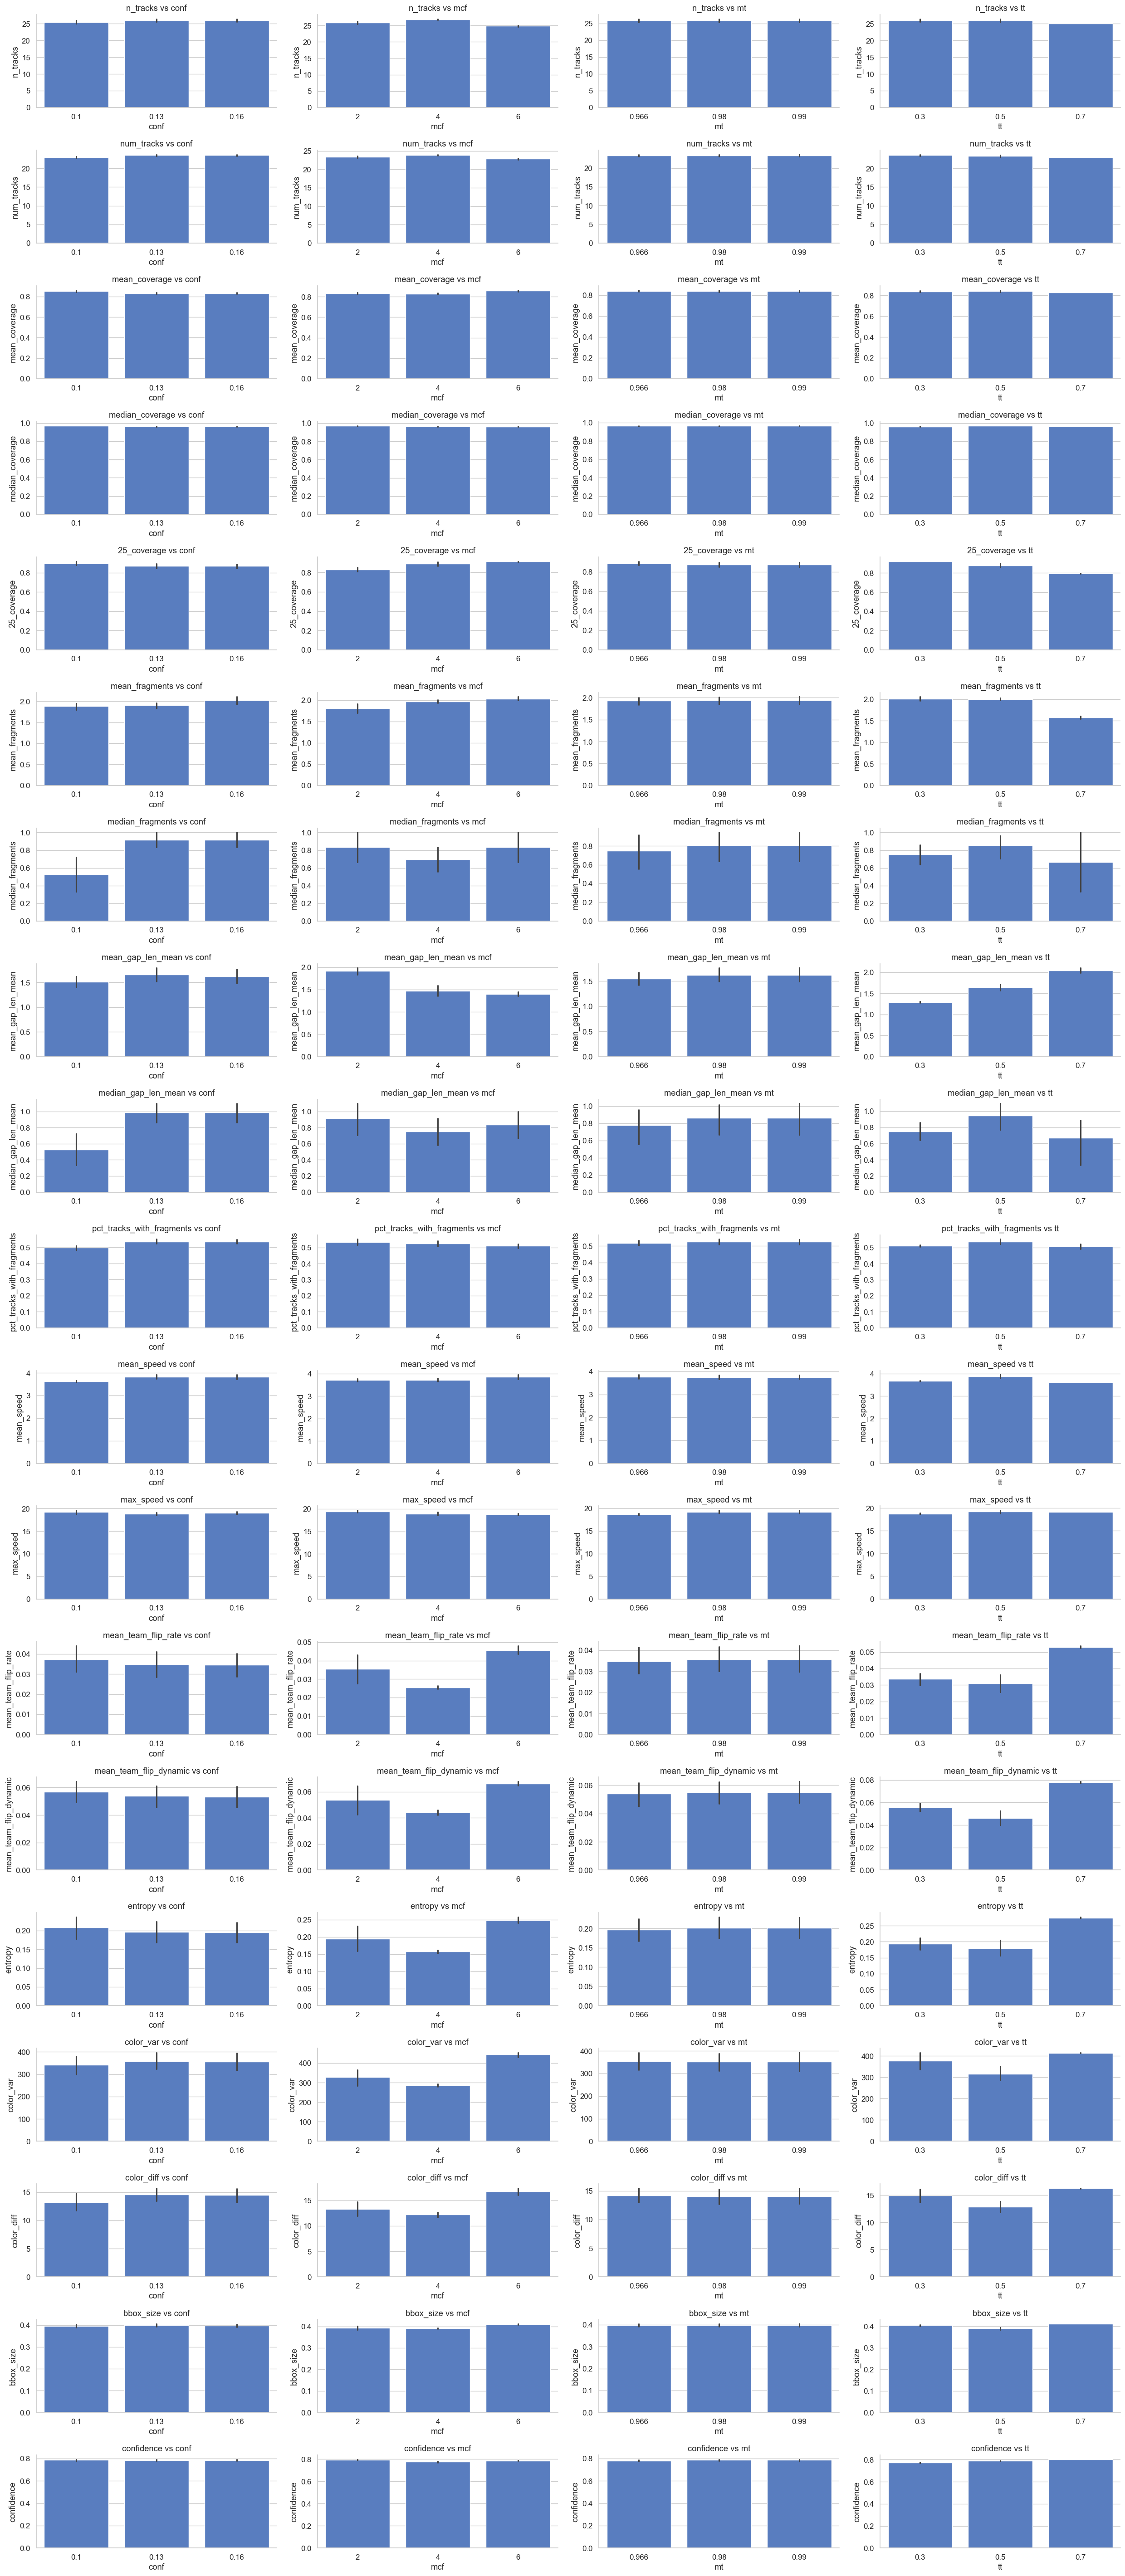

In [17]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

params = ['conf', 'mcf', 'mt', 'tt']

nrows = len(df_summary.columns[5:])
ncols = len(params)
fig, axes = plt.subplots(nrows, ncols, figsize=(25, nrows*3))
for i, c in enumerate(df_summary.columns[5:]):
    for j, p in enumerate(params):
        sns.barplot(data=df_summary, x=p, y=c, ax=axes[i, j])
        axes[i, j].set_title(f"{c} vs {p}"), axes[i, j].set_xlabel(p), axes[i, j].set_ylabel(c)

plt.tight_layout()
sns.despine()
plt.show()


In [18]:
df_summary.corr().iloc[5:, 5:]

,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,mean_fragments,median_fragments,mean_gap_len_mean,median_gap_len_mean,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
n_tracks,1.000000,0.949158,-0.672450,0.162867,-0.027907,0.258103,0.132969,-0.032643,0.255108,0.534929,0.083783,0.055343,-0.896300,-0.841051,-0.900255,-0.821452,-0.696474,-0.712387,-0.606216
num_tracks,0.949158,1.000000,-0.830854,-0.049736,-0.130154,0.195649,0.210890,0.008382,0.325785,0.590423,0.184602,-0.086821,-0.760130,-0.690829,-0.766059,-0.617359,-0.451536,-0.490271,-0.599787
mean_coverage,-0.672450,-0.830854,1.000000,0.198868,0.537791,0.241213,-0.196040,-0.378352,-0.282020,-0.507142,-0.168538,0.174591,0.325902,0.255909,0.346199,0.288475,0.096393,0.119021,0.226752
median_coverage,0.162867,-0.049736,0.198868,1.000000,-0.203971,-0.136214,-0.005619,0.414231,0.082030,0.212615,-0.109329,0.531119,-0.353965,-0.444013,-0.383895,-0.590859,-0.645107,-0.682797,0.280959
25_coverage,-0.027907,-0.130154,0.537791,-0.203971,1.000000,0.617716,-0.117742,-0.911976,-0.216960,-0.394376,-0.015833,-0.315183,-0.190131,-0.162528,-0.154716,-0.008929,-0.098754,-0.025226,-0.639069
mean_fragments,0.258103,0.195649,0.241213,-0.136214,0.617716,1.000000,0.282827,-0.606356,0.312502,0.281638,0.402800,0.037705,-0.488075,-0.520908,-0.455279,-0.190472,-0.203720,-0.335962,-0.478022
median_fragments,0.132969,0.210890,-0.196040,-0.005619,-0.117742,0.282827,1.000000,0.269735,0.971684,0.744992,0.475415,0.236691,-0.209796,-0.258068,-0.199156,0.045213,0.140970,-0.051368,0.090178
mean_gap_len_mean,-0.032643,0.008382,-0.378352,0.414231,-0.911976,-0.606356,0.269735,1.000000,0.343972,0.431060,0.075347,0.420996,0.156327,0.090718,0.116084,-0.069493,-0.009720,-0.080994,0.732405
median_gap_len_mean,0.255108,0.325785,-0.282020,0.082030,-0.216960,0.312502,0.971684,0.343972,1.000000,0.876381,0.528044,0.308943,-0.322598,-0.381580,-0.316980,-0.073182,0.036646,-0.184752,0.089233
pct_tracks_with_fragments,0.534929,0.590423,-0.507142,0.212615,-0.394376,0.281638,0.744992,0.431060,0.876381,1.000000,0.539772,0.340636,-0.540762,-0.599197,-0.546542,-0.335104,-0.191327,-0.436639,0.007694


In [19]:
df_summary.sort_values(by="median_fragments", ascending=False)

,conf,mcf,mt,tt,experiment_id,n_tracks,num_tracks,mean_coverage,median_coverage,25_coverage,...,pct_tracks_with_fragments,mean_speed,max_speed,mean_team_flip_rate,mean_team_flip_dynamic,entropy,color_var,color_diff,bbox_size,confidence
2,0.10,6,0.966,0.3,2,25,23,0.855217,0.9650,0.92250,...,0.521739,3.718905,18.971720,0.043099,0.065384,0.238702,464.749640,17.853407,0.413412,0.779623
5,0.10,6,0.980,0.3,5,25,23,0.855217,0.9650,0.92250,...,0.521739,3.718905,18.971720,0.043099,0.065384,0.238702,464.749640,17.853407,0.413412,0.779623
8,0.10,6,0.990,0.3,8,25,23,0.855217,0.9650,0.92250,...,0.521739,3.718905,18.971720,0.043099,0.065384,0.238702,464.749640,17.853407,0.413412,0.779623
15,0.10,2,0.990,0.5,15,26,23,0.865000,0.9800,0.91500,...,0.521739,3.596867,20.583230,0.019470,0.032261,0.125753,213.881664,8.700440,0.373170,0.794230
12,0.10,2,0.980,0.5,12,26,23,0.865000,0.9800,0.91500,...,0.521739,3.596867,20.583230,0.019470,0.032261,0.125753,213.881664,8.700440,0.373170,0.794230
9,0.10,2,0.966,0.5,9,26,23,0.865870,0.9800,0.92500,...,0.521739,3.730302,19.304552,0.017674,0.028568,0.115231,247.410385,9.916082,0.374116,0.776389
16,0.10,4,0.990,0.5,16,26,23,0.858261,0.9700,0.91000,...,0.521739,3.593977,20.480151,0.028660,0.044768,0.175700,257.917763,10.235620,0.382961,0.794354
32,0.13,6,0.980,0.3,32,25,23,0.852826,0.9550,0.91750,...,0.521739,3.717486,18.971720,0.040806,0.062980,0.228979,462.445383,17.607180,0.412196,0.781584
29,0.13,6,0.966,0.3,29,25,23,0.852826,0.9550,0.91750,...,0.521739,3.717486,18.971720,0.040806,0.062980,0.228979,462.445383,17.607180,0.412196,0.781584
13,0.10,4,0.980,0.5,13,26,23,0.858261,0.9700,0.91000,...,0.521739,3.593977,20.480151,0.028660,0.044768,0.175700,257.917763,10.235620,0.382961,0.794354
